### Statistiques descriptives
Ce notebook produit plusieurs statistiques descriptives sur différentes étapes de nos données (avant, après NLP).

In [2]:
import pandas as pd
pd.options.plotting.backend ='plotly'
import plotly.express as px
import matplotlib.pyplot as plt

### Description des données politiques

In [ ]:
df1 = pd.read_csv('../clean_data/struct_')
df2 = pd.read_csv('../annotations/toxicity/data_2_political_final.csv')
df = pd.concat([df1, df2])

# Remove duplicatas
df = df.drop_duplicates(subset=list(df.columns).remove('id'))

# Dataset length
print(len(df))

# Number of users
print(len(df['user'].unique()))

73019
817


In [ ]:
# Interactions by type
df['type'].hist()

In [ ]:
# Languages
df.loc[~df['language'].isin(['fr', 'en']), 'language']  = 'Other'
df['language'].hist()

In [ ]:
# Interactions par utilisateur
count_pays = df['user'].value_counts().reset_index()
count_pays.columns = ['user', 'nb_observations']

count_pays = count_pays.sort_values('nb_observations').reset_index(drop=True)

fig = px.line(
    count_pays,
    x=count_pays.index,
    y='nb_observations',
    markers=False,
    title="Nombre d'interactions par utilisateur (ordonné)"
)

fig.update_xaxes(showticklabels=True, title="Utilisateurs")
fig.update_yaxes(title="Nombre d'interactions")

fig.show()

In [ ]:
# Conversion en datetime
df['date'] = pd.to_datetime(df['date'])

obs_par_semaine = (
    df
    .set_index('date')
    .resample('W')
    .agg(
        nb_observations=('id', 'size'),
        nb_user_uniques=('user', 'nunique')
    )
    .reset_index()
)

# Plot
fig = px.line(
    obs_par_semaine,
    x='date',
    y=['nb_observations', 'nb_user_uniques'],
    markers=False,
    title="Nombre d'interactions et d'utilisateurs uniques par semaine"
)

fig.show()

In [ ]:
# Calcul de la durée de vie par utilisateur
duree_vie = (
    df
    .groupby('user')['date']
    .agg(['min', 'max'])
)

# Durée de vie en jours
duree_vie['duree_jours'] = (duree_vie['max'] - duree_vie['min']).dt.days

# Statistiques
moyenne = duree_vie['duree_jours'].mean()
q25 = duree_vie['duree_jours'].quantile(0.25)
q75 = duree_vie['duree_jours'].quantile(0.75)

print(f"Durée de vie moyenne : {moyenne:.2f} jours")
print(f"Quantile 25% : {q25:.2f} jours")
print(f"Quantile 75% : {q75:.2f} jours")

/tmp/ipykernel_7215/389172957.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["trimestre"] = df["date"].dt.to_period("Q")


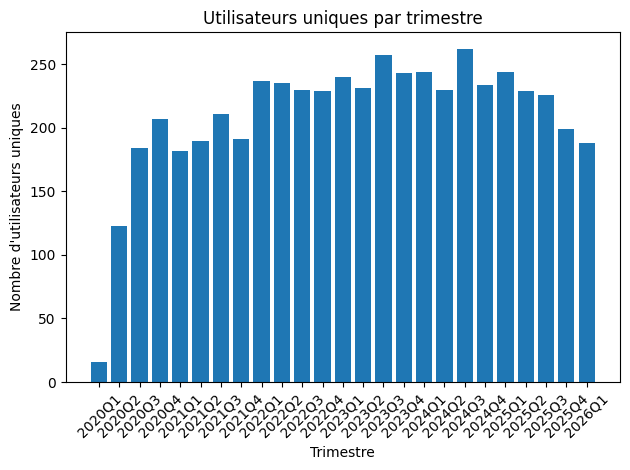

In [ ]:
# Création du trimestre
df["trimestre"] = df["date"].dt.to_period("Q")

# Nombre d'utilisateurs uniques par trimestre
quarterly_users = (
    df.groupby("trimestre")["user"]
    .nunique()
)

# Graphique
quarterly_users.index = quarterly_users.index.astype(str)
plt.bar(quarterly_users.index, quarterly_users.values)

plt.xlabel("Trimestre")
plt.ylabel("Nombre d'utilisateurs uniques")
plt.title("Utilisateurs uniques par trimestre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("UtilisateursQ.png")

### Après fusion finale de toutes les classifications NLP
Fichier `struct_panel.csv`.

In [16]:
df_total = pd.read_csv("../clean_data/struct_annotated_interactions.csv")

In [17]:
df_total = df_total[df_total["user_political"]== 1]
df_total["user"].nunique()

1117

In [18]:
df_total["date"] = pd.to_datetime(df_total['date'])
df_total["trimestre"] = df_total["date"].dt.to_period("Q")
dernier_trimestre = (
    df_total.groupby("user")["trimestre"]
    .max()
)
trimestres = pd.period_range(
    df_total["trimestre"].min(),
    df_total["trimestre"].max(),
    freq="Q"
)

survie = []

for t in trimestres:
    nb = (dernier_trimestre >= t).sum()
    survie.append({
        "trimestre": t.to_timestamp(),
        "nb_actifs": nb
    })

survie_df = pd.DataFrame(survie)

C:\Users\cfrou\AppData\Local\Temp\ipykernel_43416\3952445522.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_total["trimestre"] = df_total["date"].dt.to_period("Q")


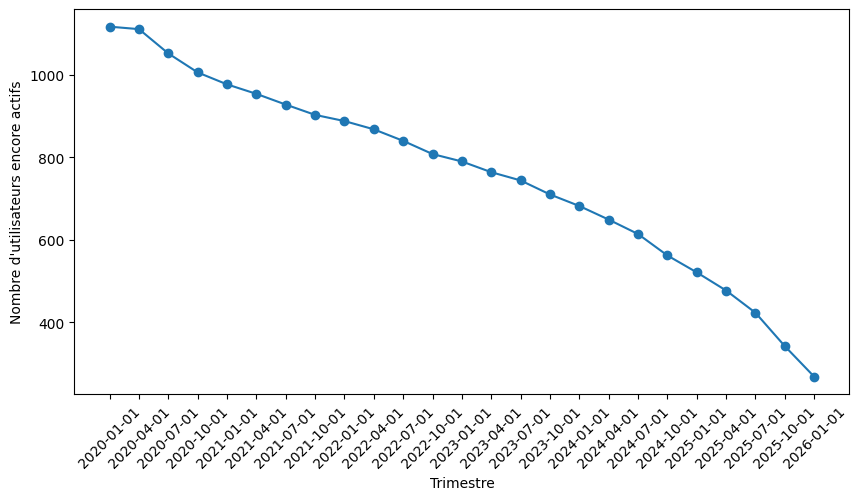

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    survie_df["trimestre"].astype(str),
    survie_df["nb_actifs"]
    ,marker="o"
)

plt.xlabel("Trimestre")
plt.ylabel("Nombre d'utilisateurs encore actifs")
#plt.title("Survie des utilisateurs Reddit")
plt.xticks(rotation=45)
plt.savefig("UtilisateursQ.png")

In [20]:
commentaires_trimestre = (
    df_total.groupby("trimestre")
    .size()
    .reset_index(name="nb_commentaires")
)

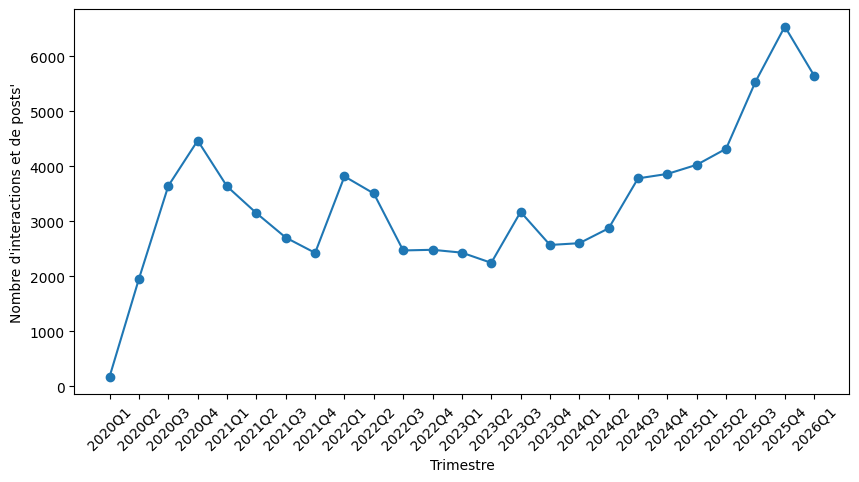

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(
    commentaires_trimestre["trimestre"].astype(str),
    commentaires_trimestre["nb_commentaires"],
    marker="o"
)

plt.xlabel("Trimestre")
plt.ylabel("Nombre d'interactions et de posts'")
#plt.title("Nombre d'interactions et de posts par trimestre")

plt.xticks(rotation=45)

plt.savefig("CommentairesQ.png")

In [22]:
# Proportion de commentaires violent par trimestre
tox_par_trim = (
    df_total.groupby("trimestre")["user_violent"]
    .mean()
    .reset_index(name="proportion_violent")
)

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(
    tox_par_trim["trimestre"].astype(str),
    tox_par_trim["proportion_toxique"],
    marker="o"
)

plt.xlabel("Trimestre")
plt.ylabel("Proportion de productions toxiques")
plt.title("Évolution de la toxicité des productions")

#plt.ylim(0, 1)
plt.xticks(rotation=45)

plt.savefig("ProductionsToxiques.png")

KeyError: 'proportion_toxique'

<Figure size 1000x500 with 0 Axes>

In [ ]:
repartition = (
    df.groupby(["trimestre", "user_left_right"])
    .size()
    .unstack(fill_value=0)
)

In [ ]:
repartition_prop = repartition.div(
    repartition.sum(axis=1),
    axis=0
)

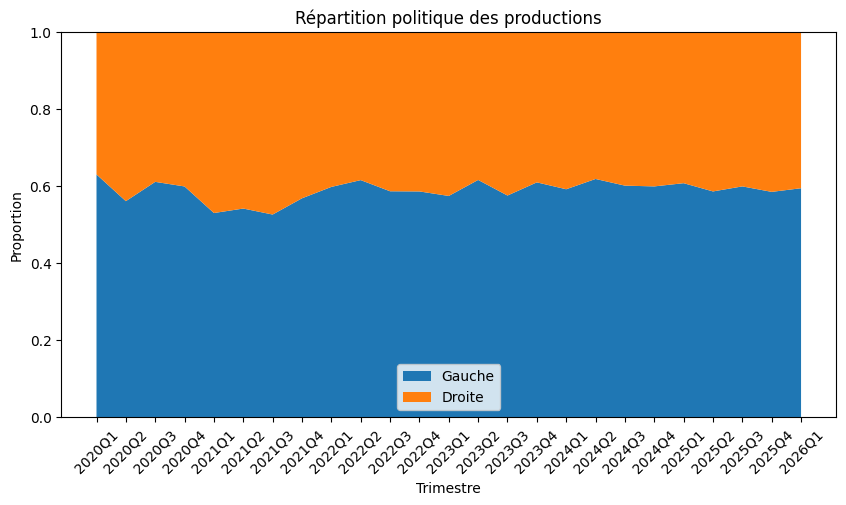

In [ ]:
plt.figure(figsize=(10, 5))

plt.stackplot(
    repartition_prop.index.astype(str),
    repartition_prop["Left"],
    repartition_prop["Right"],
    labels=["Gauche", "Droite"]
)

plt.ylabel("Proportion")
plt.xlabel("Trimestre")
plt.title("Répartition politique des productions")

plt.ylim(0, 1)
plt.legend()
plt.xticks(rotation=45)

plt.show()

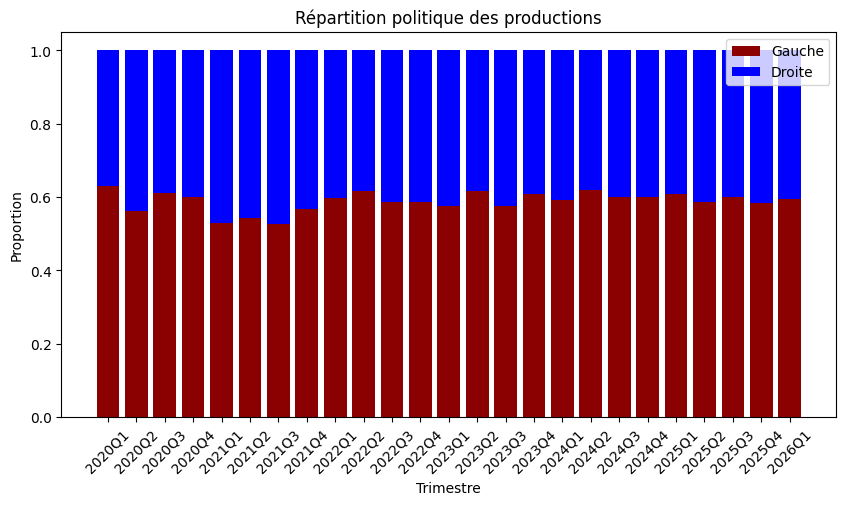

In [ ]:

x = repartition_prop.index.astype(str)
gauche = repartition_prop["Left"].values
droite = repartition_prop["Right"].values

plt.figure(figsize=(10, 5))

plt.bar(x, gauche, color='darkred', label="Gauche")
plt.bar(x, droite, bottom=gauche, color='blue', label="Droite")

plt.ylabel("Proportion")
plt.xlabel("Trimestre")
plt.title("Répartition politique des productions")

plt.legend()
plt.xticks(rotation=45)

plt.savefig("RepartitionG.png")